# Accuracy and Efficiency Figures

This notebook selects the trained MLP and KAN models, evaluates them on the far field, and saves two figures.

In [1]:
import os
import sys
from datetime import datetime
import itertools

from importlib import reload
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utils')
os.chdir(current_dir)
if utilities_dir not in sys.path:
    sys.path.insert(0, utilities_dir)
import plotting
import pinns
import infinite
reload(plotting)
reload(pinns)
reload(infinite)
import numpy as np
import sympy as sp
import pandas as pd
import matplotlib.pyplot as plt 
import matplotlib.ticker as ticker
import torch
import torch.nn as nn
import torch.optim as optim
from pinns import  MLP, init_weights, CoefficientNet, pde_loss_inf, observation_loss_u, observation_loss_k, train_dual_network, build_models, set_seed,run_experiment_inf,build_models_KAN
from pinns import build_models
from infinite import analytical_solution_inf, coefficient_inf, source_term_inf, generate_dataset_inf, evaluate_model_inf
torch.set_default_dtype(torch.float32)
from plotting import plot_histories_comparison

set_seed(1)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

/home/orincon/miniconda3/envs/PIKAN-unbounded-domains-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Experiment Summary

In [2]:
 
mlp_results_dir = "results_accuracy_efficiency_2026-09-14_11-02-44"
kan_results_dir = "results_accuracy_efficiency_2026-09-14_11-13-10"

mlp_csv = os.path.join(
    mlp_results_dir,
    "summary_metrics.csv"
)

kan_csv = os.path.join(
    kan_results_dir,
    "summary_metrics.csv"
)

df_mlp = pd.read_csv(mlp_csv)
df_kan = pd.read_csv(kan_csv)

df_mlp.columns = df_mlp.columns.str.strip()
df_kan.columns = df_kan.columns.str.strip()

# Global mean error
df_mlp["err_global_mean"] = df_mlp[
    ["err_u_global", "err_k_global"]
].mean(axis=1)

df_kan["err_global_mean"] = df_kan[
    ["err_u_global", "err_k_global"]
].mean(axis=1)

target_error = 1e-2

mlp_csv = os.path.join(
    mlp_results_dir,
    "summary_metrics.csv"
)

kan_csv = os.path.join(
    kan_results_dir,
    "summary_metrics.csv"
)

 
# Combine both experiments
df = pd.concat(
    [df_mlp, df_kan],
    ignore_index=True
)

print(f"MLP runs: {len(df_mlp)}")
print(f"KAN runs: {len(df_kan)}")
print(f"Total runs: {len(df)}")

MLP runs: 9
KAN runs: 9
Total runs: 18


## Trade-off Figure

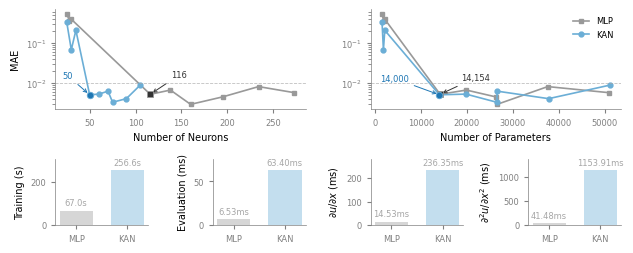

Figure successfully saved to figures/tradeoff.svg


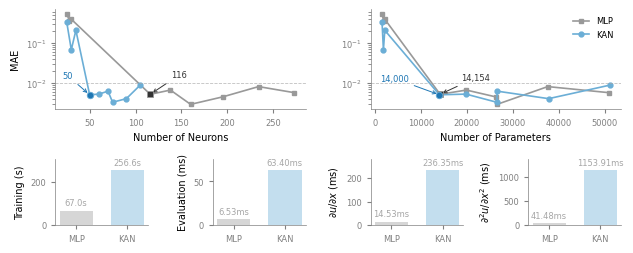

In [3]:
from figure_tradeoff import plot_tradeoff

# Prepare the experiment-summary data used by the trade-off figure.
df_mlp = df[df["model_type"] == "MLP"].copy()
df_kan = df[df["model_type"] == "KAN"].copy()

plot_tradeoff(
    df_mlp,
    df_kan,
    output_dir="figures",
    target_error=target_error,
)


## Model Selection

In [4]:
# =========================================================
# Select Models
# =========================================================

target_error = 1e-2

# ---------------------------------------------------------
# MLP
# ---------------------------------------------------------

mlp_sorted = df_mlp.sort_values("parameters")

mlp_achieved = mlp_sorted[
    mlp_sorted["err_global_mean"] <= target_error
]

if not mlp_achieved.empty:
    mlp_selected = mlp_achieved.iloc[0]
else:
    idx = (
        mlp_sorted["err_global_mean"] - target_error
    ).abs().idxmin()

    mlp_selected = mlp_sorted.loc[idx]


# ---------------------------------------------------------
# KAN
# ---------------------------------------------------------

kan_sorted = df_kan.sort_values("parameters")

kan_achieved = kan_sorted[
    kan_sorted["err_global_mean"] <= target_error
]

if not kan_achieved.empty:
    kan_selected = kan_achieved.iloc[0]
else:
    idx = (
        kan_sorted["err_global_mean"] - target_error
    ).abs().idxmin()

    kan_selected = kan_sorted.loc[idx]


print("\nSelected MLP:")
print(mlp_selected)

print("\nSelected KAN:")
print(kan_selected)


Selected MLP:
model_type                                   MLP
hidden_layers                                  2
hidden_units                                  58
adam_lr                                    0.001
adam_iters                                  2000
lbfgs_iters                                 2000
activation                                Tanh()
grid_size                                    NaN
spline_order                                 NaN
sampling                                gaussian
sigma                                        5.5
exp_scale                                    1.0
n_obs_u                                      100
n_obs_k                                      100
n_pde                                       1000
seed                                           2
lambda_pde_scheduler                        True
adaptive_weights                            True
alpha                                          7
update_every                                 100
regul

## Load Selected Models

In [5]:
mlp_run_dir = os.path.join(
    mlp_results_dir,"MLP",
    str(mlp_selected["timestamp"])
)

kan_run_dir = os.path.join(
    kan_results_dir,"KAN",
    str(kan_selected["timestamp"])
)

mlp_model_u_path = os.path.join(
    mlp_run_dir,
    "model_u.pt"
)

mlp_model_k_path = os.path.join(
    mlp_run_dir,
    "model_k.pt"
)

kan_model_u_path = os.path.join(
    kan_run_dir,
    "model_u.pt"
)

kan_model_k_path = os.path.join(
    kan_run_dir,
    "model_k.pt"
)


import os
import json
import torch

# =========================================================
# Load MLP configuration
# =========================================================

with open(
    os.path.join(
        mlp_run_dir,
        "run_metrics_and_config.json"
    ),
    "r"
) as f:
    mlp_config = json.load(f)

# =========================================================
# Build MLP with the stored architecture
# =========================================================

model_u_mlp, model_k_mlp = build_models(
    device=device,
    hidden_layers=mlp_config["hidden_layers"],
    hidden_units=mlp_config["hidden_units"],
    activation=nn.Tanh(),
)

# =========================================================
# Load trained weights
# =========================================================

model_u_mlp.load_state_dict(
    torch.load(
        os.path.join(
            mlp_run_dir,
            "model_u.pt"
        ),
        map_location=device
    )
)

model_k_mlp.load_state_dict(
    torch.load(
        os.path.join(
            mlp_run_dir,
            "model_k.pt"
        ),
        map_location=device
    )
)

model_u_mlp.eval()
model_k_mlp.eval()


# =========================================================
# Load KAN configuration
# =========================================================

with open(
    os.path.join(
        kan_run_dir,
        "run_metrics_and_config.json"
    ),
    "r"
) as f:
    kan_config = json.load(f)

# =========================================================
# Build KAN with the stored architecture
# =========================================================

model_u_kan, model_k_kan = build_models_KAN(
    device=device,
    hidden_layers=kan_config["hidden_layers"],
    hidden_units=kan_config["hidden_units"],
    grid_size=kan_config["grid_size"],
    spline_order=kan_config["spline_order"],
)

# =========================================================
# Load trained weights
# =========================================================

model_u_kan.load_state_dict(
    torch.load(
        os.path.join(
            kan_run_dir,
            "model_u.pt"
        ),
        map_location=device
    )
)

model_k_kan.load_state_dict(
    torch.load(
        os.path.join(
            kan_run_dir,
            "model_k.pt"
        ),
        map_location=device
    )
)

model_u_kan.eval()
model_k_kan.eval()

KAN(
  (layers): ModuleList(
    (0-2): 3 x KANLinear(
      (base_activation): SiLU()
    )
  )
)

## Far-field Figure


Far-field evaluation
MLP outside MAE: 2.0173e-02
KAN outside MAE: 1.7172e+00

Square-ring MAE
   0–5 : MLP = 2.017795e-02    KAN = 1.503436e-02
  5–10 : MLP = 5.172844e-03    KAN = 6.229723e-03
 10–15 : MLP = 9.615697e-03    KAN = 3.684306e-02
 15–20 : MLP = 1.367868e-02    KAN = 1.786302e-01
 20–25 : MLP = 1.687258e-02    KAN = 4.946534e-01
 25–30 : MLP = 1.915135e-02    KAN = 1.072612e+00
 30–35 : MLP = 2.085558e-02    KAN = 1.711957e+00
 35–40 : MLP = 2.237035e-02    KAN = 2.177182e+00
 40–45 : MLP = 2.360415e-02    KAN = 2.537336e+00
 45–50 : MLP = 2.459310e-02    KAN = 2.855061e+00


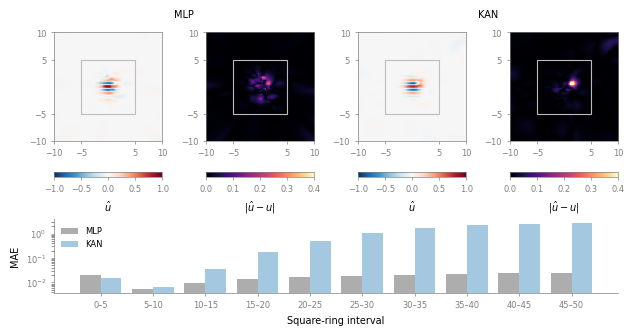

Figure successfully saved to figures/far_field.svg


In [6]:
from figure_far_field import plot_far_field

# Evaluation domain used for predictions and square-ring MAE.
eval_xmin = -50.0
eval_xmax = 50.0
eval_ymin = -50.0
eval_ymax = 50.0
n_grid = 400

x = np.linspace(eval_xmin, eval_xmax, n_grid)
y = np.linspace(eval_ymin, eval_ymax, n_grid)
X, Y = np.meshgrid(x, y)

alpha = mlp_config["pde_alpha"]
beta = mlp_config["pde_beta"]
U = analytical_solution_inf(X, Y, alpha, beta)

X_test = torch.tensor(
    np.column_stack([X.ravel(), Y.ravel()]),
    dtype=torch.float32,
    device=device,
)

model_u_mlp.eval()
model_u_kan.eval()
with torch.no_grad():
    U_pred_mlp = model_u_mlp(X_test).cpu().numpy().reshape(U.shape)
    U_pred_kan = model_u_kan(X_test).cpu().numpy().reshape(U.shape)

outside_mask = (
    (X < -5.0)
    | (X > 5.0)
    | (Y < -5.0)
    | (Y > 5.0)
)

error_mlp = np.abs(U_pred_mlp - U)
error_kan = np.abs(U_pred_kan - U)
print("\n========================================")
print("Far-field evaluation")
print("========================================")
print(f"MLP outside MAE: {np.mean(error_mlp[outside_mask]):.4e}")
print(f"KAN outside MAE: {np.mean(error_kan[outside_mask]):.4e}")

palette = {
    "kan": "#1F77B4",
    "mlp": "#333333",
}

fig, mae_mlp, mae_kan = plot_far_field(
    U_pred_mlp,
    U_pred_kan,
    U,
    x,
    y,
    palette,
    output_dir="figures",
)
